# Which marketing experiment should we run next?

## Ranking evidence-gathering actions by identification gain

A B2B growth team wants to estimate the causal effect of **personalised outbound
outreach** on **qualified sales pipeline**.

Its current CRM data are observational. The main uncertainty is whether unmeasured
**account purchase intent** drives both:

- which accounts receive personalised outreach; and
- which accounts create pipeline.

The team has several ways to spend its research budget:

1. purchase a better account-intent signal;
2. run a randomised outreach holdout;
3. collect data in a new territory;
4. simply wait for more accounts.

This notebook uses Antecedent to rank those actions by how much they increase the
probability that the outreach effect is identifiable. It then applies a **£40,000
budget constraint** and simulates the recommended action.

The scenario and data are synthetic, but they represent a realistic revenue-operations
decision. The causal truth is known so the result can be checked.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iridae-dev/antecedent/blob/main/examples/notebooks/marketing_experiment_design.ipynb)

**Repository:** <https://github.com/iridae-dev/antecedent>  
**Documentation:** <https://antecedent.readthedocs.io/>

## Environment: the 1.10 Python API

Use a kernel with the built **1.10.0 branch**, NumPy, pandas and Matplotlib.
See the [local and Colab setup instructions](../README.md#python-environment-110-branch).
These examples use the new API before the 1.10 release; installing an older
published wheel will not provide `prepare`, `load`, or retained studies.


In [1]:
# Use the built 1.10.0 branch (see examples/README.md for local/Colab setup).
import antecedent

if not all(hasattr(antecedent, name) for name in ("prepare", "load")):
    raise RuntimeError(
        "This notebook requires the 1.10 Python API. Build/install the 1.10.0 "
        "branch, then restart the kernel; the older PyPI wheels lack this API."
    )


In [2]:
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import antecedent
from antecedent import AverageEffect, analyze

print("antecedent", version("antecedent"))

antecedent 1.9.0


## 2. The causal question

The target estimand is:

$$
\text{ATE}
=
E[
  \text{pipeline}\mid do(\text{personalised outreach}=1)
]
-
E[
  \text{pipeline}\mid do(\text{personalised outreach}=0)
]
$$

Pipeline is measured in **£ thousands per account**.

The current structural posterior contains four material causal hypotheses. Only one
currently identifies the effect using the variables already present in the CRM.

In [3]:
graph_hypotheses = pd.DataFrame(
    [
        {
            "graph_key": 101,
            "hypothesis": "Purchase intent confounds outreach and pipeline",
            "posterior_weight": 0.40,
            "effect_identified_now": False,
        },
        {
            "graph_key": 102,
            "hypothesis": "Intent and account size jointly drive assignment",
            "posterior_weight": 0.20,
            "effect_identified_now": False,
        },
        {
            "graph_key": 103,
            "hypothesis": "Observed account size is a sufficient adjustment set",
            "posterior_weight": 0.25,
            "effect_identified_now": True,
        },
        {
            "graph_key": 104,
            "hypothesis": "Buying-stage intent drives outreach and pipeline",
            "posterior_weight": 0.15,
            "effect_identified_now": False,
        },
    ]
)

graph_hypotheses

,graph_key,hypothesis,posterior_weight,effect_identified_now
0,101,Purchase intent confounds outreach and pipeline,0.40,False
1,102,Intent and account size jointly drive assignment,0.20,False
2,103,Observed account size is a sufficient adjustme...,0.25,True
3,104,Buying-stage intent drives outreach and pipeline,0.15,False


In [4]:
baseline_identification_probability = float(
    graph_hypotheses.loc[
        graph_hypotheses["effect_identified_now"],
        "posterior_weight",
    ].sum()
)

print(
    "Current probability that the outreach effect is identifiable:",
    f"{baseline_identification_probability:.0%}",
)

Current probability that the outreach effect is identifiable: 25%


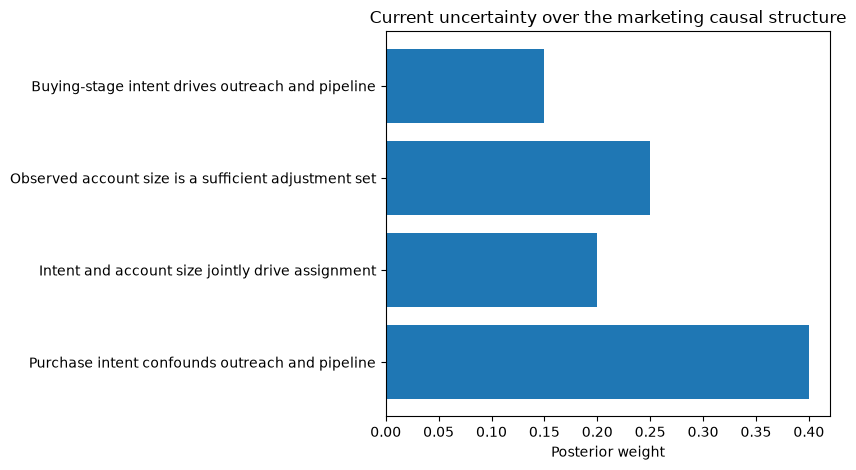

In [5]:
plt.figure(figsize=(8.5, 4.8))
plt.barh(
    graph_hypotheses["hypothesis"],
    graph_hypotheses["posterior_weight"],
)
plt.xlabel("Posterior weight")
plt.title("Current uncertainty over the marketing causal structure")
plt.tight_layout()
plt.show()

## 3. Candidate research actions

Antecedent's design API uses stable integer IDs for registered variables, queries,
environments and graph hypotheses.

In this planning model:

- variable `0` is personalised outreach;
- variable `3` is the currently unavailable purchase-intent measure;
- query `0` is the outreach-to-pipeline ATE;
- environment `7` is a proposed new sales territory.

The declared cost is a caller-owned scalar. Here it is expressed directly in pounds.

In [6]:
candidates = [
    {
        "kind": "intervene",
        "targets": [0],
        "tag": 100,
        "cost": 60_000.0,
        "sample_budget": 800,
    },
    {
        "kind": "measure",
        "variables": [3],
        "tag": 200,
        "cost": 25_000.0,
        "sample_budget": 0,
    },
    {
        "kind": "observe_environment",
        "environment": 7,
        "additional_rows": 300,
        "tag": 300,
        "cost": 35_000.0,
        "sample_budget": 300,
    },
    {
        "kind": "increase_sampling_rate",
        "additional_samples": 500,
        "tag": 400,
        "cost": 15_000.0,
        "sample_budget": 500,
    },
]

candidate_catalogue = pd.DataFrame(
    [
        {
            "candidate_index": 0,
            "action": "Randomised outreach holdout",
            "kind": "intervene",
            "cost_gbp": 60_000,
            "business interpretation": (
                "Randomise personalised outreach so assignment no longer "
                "depends on account intent"
            ),
        },
        {
            "candidate_index": 1,
            "action": "Purchase account-intent measurement",
            "kind": "measure",
            "cost_gbp": 25_000,
            "business interpretation": (
                "Measure the missing pre-treatment variable required by "
                "the current identification analysis"
            ),
        },
        {
            "candidate_index": 2,
            "action": "Add a new sales territory",
            "kind": "observe_environment",
            "cost_gbp": 35_000,
            "business interpretation": (
                "Observe 300 more accounts in a different territory"
            ),
        },
        {
            "candidate_index": 3,
            "action": "Wait for 500 more CRM accounts",
            "kind": "increase_sampling_rate",
            "cost_gbp": 15_000,
            "business interpretation": (
                "Increase sample size without changing what is measured "
                "or how outreach is assigned"
            ),
        },
    ]
)

candidate_catalogue

,candidate_index,action,kind,cost_gbp,business interpretation
0,0,Randomised outreach holdout,intervene,60000,Randomise personalised outreach so assignment ...
1,1,Purchase account-intent measurement,measure,25000,Measure the missing pre-treatment variable req...
2,2,Add a new sales territory,observe_environment,35000,Observe 300 more accounts in a different terri...
3,3,Wait for 500 more CRM accounts,increase_sampling_rate,15000,Increase sample size without changing what is ...


## 4. Encode what each action can resolve

The planning assumptions are explicit:

- measuring purchase intent unlocks the registered query;
- randomising outreach identifies the effect under every current graph hypothesis;
- another territory does not, by itself, remove the missing-confounder problem;
- more rows of the same observational data improve precision but do not create
  identification.

These are design assumptions supplied to the ranker. Antecedent does not infer them
from the action labels.

In [7]:
graph_weights = graph_hypotheses["posterior_weight"].tolist()
identified_now = (
    graph_hypotheses["effect_identified_now"].astype(int).tolist()
)
graph_keys = graph_hypotheses["graph_key"].tolist()

query_id = 0
purchase_intent_variable_id = 3

# A measured purchase-intent variable is sufficient to unlock query 0.
query_id_unlock = [
    (query_id, [purchase_intent_variable_id]),
]

# A randomised outreach intervention identifies the effect under every
# currently weighted graph hypothesis.
identified_under_intervention = [1, 1, 1, 1]

## 5. Rank actions by identification gain

`increase_identification_probability` scores the increase over the current identified
posterior mass. A score of `0.75`, for example, moves the analysis from 25% identified
mass to 100%.

Higher scores are better.

In [8]:
unconstrained_ranking = antecedent.design.rank_designs(
    graph_weights,
    identified_now,
    graph_keys,
    candidates,
    objective="increase_identification_probability",
    query_id=query_id,
    query_id_unlock=query_id_unlock,
    identified_under_intervention=identified_under_intervention,
    min_batches=2,
    max_batches=8,
    batch_size=8,
    rank_uncertainty_threshold=0.01,
    seed=11,
)

print(
    "Monte Carlo samples:",
    unconstrained_ranking.mc_samples,
    "| early stopped:",
    unconstrained_ranking.early_stopped,
)

Monte Carlo samples: 16 | early stopped: True


In [9]:
unconstrained_rows = []

for ranked in unconstrained_ranking.ranked:
    details = candidate_catalogue.loc[
        candidate_catalogue["candidate_index"] == ranked.candidate_index
    ].iloc[0]

    post_identification_probability = min(
        1.0,
        baseline_identification_probability + ranked.score,
    )

    unconstrained_rows.append(
        {
            "rank": ranked.rank + 1,
            "candidate_index": ranked.candidate_index,
            "action": details["action"],
            "kind": ranked.kind,
            "identification_gain": ranked.score,
            "identification_probability_after": (
                post_identification_probability
            ),
            "cost_gbp": details["cost_gbp"],
            "score_stderr": ranked.stderr,
            "rank_uncertain": ranked.rank_uncertain,
        }
    )

unconstrained_table = pd.DataFrame(unconstrained_rows)
unconstrained_table

,rank,candidate_index,action,kind,identification_gain,identification_probability_after,cost_gbp,score_stderr,rank_uncertain
0,1,0,Randomised outreach holdout,intervene,0.75,1.00,60000,0.0,False
1,2,1,Purchase account-intent measurement,measure,0.75,1.00,25000,0.0,False
2,3,2,Add a new sales territory,observe_environment,0.00,0.25,35000,0.0,False
3,4,3,Wait for 500 more CRM accounts,increase_sampling_rate,0.00,0.25,15000,0.0,False


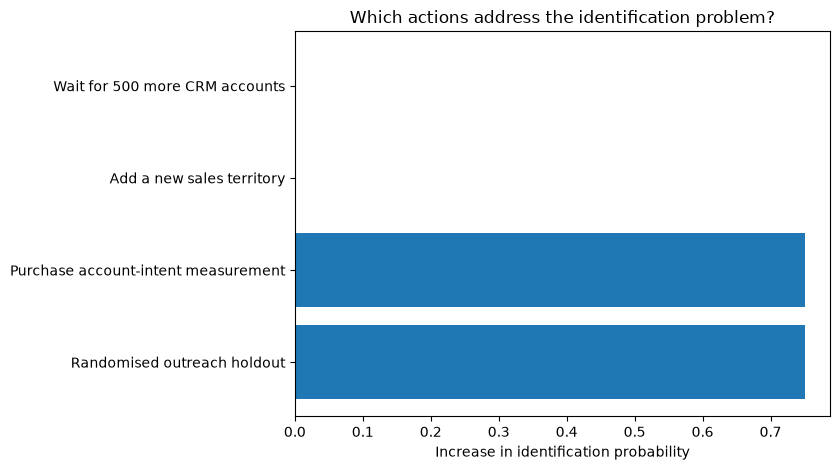

In [10]:
plt.figure(figsize=(8.5, 4.8))
plt.barh(
    unconstrained_table["action"],
    unconstrained_table["identification_gain"],
)
plt.xlabel("Increase in identification probability")
plt.title("Which actions address the identification problem?")
plt.tight_layout()
plt.show()

The randomised holdout and the intent measurement can both resolve the current
identification problem under the declared planning assumptions.

Collecting more of the same observational data receives no identification gain.
This does **not** mean more data are worthless: they can improve precision after the
estimand is identified. It means sample size alone cannot repair a missing causal
assumption or an unmeasured confounder.

## 6. Add a transparent cost-efficiency view

The design objective above optimises identification gain, not pounds spent. We can
combine the engine's score with business-owned costs after ranking.

This ratio is deliberately simple: identification-probability gain per £1,000.
It is a reporting calculation, not a hidden modification of Antecedent's objective.

In [11]:
unconstrained_table["gain_per_£1k"] = np.where(
    unconstrained_table["cost_gbp"] > 0,
    unconstrained_table["identification_gain"]
    / (unconstrained_table["cost_gbp"] / 1_000),
    np.nan,
)

cost_efficiency = unconstrained_table.sort_values(
    ["gain_per_£1k", "identification_gain"],
    ascending=False,
).reset_index(drop=True)

cost_efficiency[
    [
        "action",
        "identification_gain",
        "cost_gbp",
        "gain_per_£1k",
    ]
]

,action,identification_gain,cost_gbp,gain_per_£1k
0,Purchase account-intent measurement,0.75,25000,0.0300
1,Randomised outreach holdout,0.75,60000,0.0125
2,Add a new sales territory,0.00,35000,0.0000
3,Wait for 500 more CRM accounts,0.00,15000,0.0000


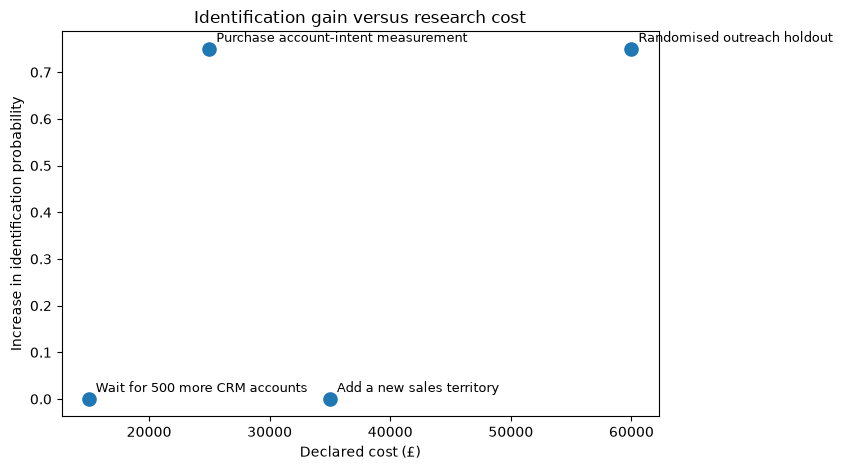

In [12]:
plt.figure(figsize=(8.5, 4.8))
plt.scatter(
    unconstrained_table["cost_gbp"],
    unconstrained_table["identification_gain"],
    s=90,
)

for _, row in unconstrained_table.iterrows():
    plt.annotate(
        row["action"],
        (row["cost_gbp"], row["identification_gain"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

plt.xlabel("Declared cost (£)")
plt.ylabel("Increase in identification probability")
plt.title("Identification gain versus research cost")
plt.tight_layout()
plt.show()

## 7. Apply the £40,000 budget

Hard constraints are applied before scoring. Candidates that violate them are recorded
explicitly rather than silently disappearing.

In [13]:
budget_gbp = 40_000.0

constrained_ranking = antecedent.design.rank_designs(
    graph_weights,
    identified_now,
    graph_keys,
    candidates,
    objective="increase_identification_probability",
    query_id=query_id,
    query_id_unlock=query_id_unlock,
    identified_under_intervention=identified_under_intervention,
    max_cost=budget_gbp,
    min_batches=2,
    max_batches=8,
    batch_size=8,
    rank_uncertainty_threshold=0.01,
    seed=11,
)

constrained_rows = []

for ranked in constrained_ranking.ranked:
    details = candidate_catalogue.loc[
        candidate_catalogue["candidate_index"] == ranked.candidate_index
    ].iloc[0]

    constrained_rows.append(
        {
            "rank": ranked.rank + 1,
            "candidate_index": ranked.candidate_index,
            "action": details["action"],
            "cost_gbp": details["cost_gbp"],
            "identification_gain": ranked.score,
            "identification_probability_after": min(
                1.0,
                baseline_identification_probability + ranked.score,
            ),
        }
    )

constrained_table = pd.DataFrame(constrained_rows)
constrained_table

,rank,candidate_index,action,cost_gbp,identification_gain,identification_probability_after
0,1,1,Purchase account-intent measurement,25000,0.75,1.00
1,2,2,Add a new sales territory,35000,0.00,0.25
2,3,3,Wait for 500 more CRM accounts,15000,0.00,0.25


In [14]:
violations = pd.DataFrame(
    [
        {
            "candidate_index": violation.candidate_index,
            "action": candidate_catalogue.loc[
                candidate_catalogue["candidate_index"]
                == violation.candidate_index,
                "action",
            ].iloc[0],
            "constraint": violation.constraint,
            "detail": violation.detail,
        }
        for violation in constrained_ranking.violations
    ]
)

violations

,candidate_index,action,constraint,detail
0,0,Randomised outreach holdout,max_cost,cost 60000 exceeds max_cost 40000


In [15]:
selected_index = constrained_ranking.best_index
selected_action = candidate_catalogue.loc[
    candidate_catalogue["candidate_index"] == selected_index,
    "action",
].iloc[0]

print("Recommended action under the budget:", selected_action)

Recommended action under the budget: Purchase account-intent measurement


Under the £40,000 constraint, the randomised holdout is infeasible. Measuring account
intent is the highest-ranked feasible action because it directly addresses the current
identification gap.

The recommendation is advisory. The library does not purchase data, launch an
experiment, or automatically rerun an analysis.

## 8. Simulate the recommended action

We now simulate account-level CRM data.

The true data-generating process is:

$$
\text{account size} \rightarrow \text{outreach}
$$

$$
\text{account size} \rightarrow \text{pipeline}
$$

$$
\text{purchase intent} \rightarrow \text{outreach}
$$

$$
\text{purchase intent} \rightarrow \text{pipeline}
$$

$$
\text{outreach} \rightarrow \text{pipeline}
$$

The true incremental effect of personalised outreach is **£12,000 of qualified
pipeline per account**.

In [16]:
DATA_SEED = 31
N_ACCOUNTS = 1_200
TRUE_EFFECT_KGBP = 12.0

rng = np.random.default_rng(DATA_SEED)

account_size_score = rng.normal(size=N_ACCOUNTS)
purchase_intent_score = rng.normal(size=N_ACCOUNTS)

assignment_score = (
    0.8 * account_size_score
    + 1.1 * purchase_intent_score
    + rng.normal(size=N_ACCOUNTS)
)
personalised_outreach = (assignment_score > 0).astype(float)

qualified_pipeline_kgbp = (
    50.0
    + TRUE_EFFECT_KGBP * personalised_outreach
    + 9.0 * account_size_score
    + 14.0 * purchase_intent_score
    + 5.0 * rng.normal(size=N_ACCOUNTS)
)

crm = pd.DataFrame(
    {
        "account_size_score": account_size_score,
        "purchase_intent_score": purchase_intent_score,
        "personalised_outreach": personalised_outreach,
        "qualified_pipeline_kgbp": qualified_pipeline_kgbp,
    }
)

crm.head()

,account_size_score,purchase_intent_score,personalised_outreach,qualified_pipeline_kgbp
0,-0.395301,1.698390,1.0,92.192484
1,0.263915,1.419088,1.0,87.669168
2,0.607128,1.438445,1.0,94.185177
3,-0.972160,1.071881,0.0,61.887541
4,0.767664,0.521993,1.0,81.010654


Before purchasing the intent signal, the CRM contains account size, outreach and
pipeline. The raw difference between contacted and uncontacted accounts is biased
because high-intent accounts are more likely to receive the campaign.

In [17]:
naive_difference = (
    crm.loc[
        crm["personalised_outreach"] == 1,
        "qualified_pipeline_kgbp",
    ].mean()
    - crm.loc[
        crm["personalised_outreach"] == 0,
        "qualified_pipeline_kgbp",
    ].mean()
)

print(
    "Naive treated-minus-untreated difference:",
    f"£{naive_difference:,.2f}k per account",
)
print(
    "True causal effect:",
    f"£{TRUE_EFFECT_KGBP:,.2f}k per account",
)

Naive treated-minus-untreated difference: £34.54k per account
True causal effect: £12.00k per account


After the intent measurement is available, the reviewed graph contains an observed
backdoor adjustment set: account size and purchase intent.

In [18]:
measured_data = {
    "account_size_score": crm["account_size_score"].to_numpy(),
    "purchase_intent_score": crm["purchase_intent_score"].to_numpy(),
    "personalised_outreach": crm["personalised_outreach"].to_numpy(),
    "qualified_pipeline_kgbp": crm["qualified_pipeline_kgbp"].to_numpy(),
}

reviewed_graph = [
    ("account_size_score", "personalised_outreach"),
    ("account_size_score", "qualified_pipeline_kgbp"),
    ("purchase_intent_score", "personalised_outreach"),
    ("purchase_intent_score", "qualified_pipeline_kgbp"),
    ("personalised_outreach", "qualified_pipeline_kgbp"),
]

measured_result = analyze(
    data=measured_data,
    graph=reviewed_graph,
    query=AverageEffect(
        treatment="personalised_outreach",
        outcome="qualified_pipeline_kgbp",
    ),
    seed=DATA_SEED,
)

measured_result

Refuter,Original,Refuted,Comparison,Result
placebo.treatment,11.624,-0.029,0.899,pass
random.common_cause,11.624,11.625,0.946,pass


### Keep the study and inspect the evidence

The analysis call also retains a reusable study. `study.estimate()` uses the
retained data; `study.refresh(new_data)` replaces it after a successful run.
Earlier results remain tied to their own execution. The report includes the
answer shape, identification, uncertainty, assumptions, support and calibration.
`unavailable` calibration means no calibration evidence is bound to this result;
it is not inferred from a passing refutation or an identified graph.


In [19]:
study = measured_result.study
report = measured_result.inspect().to_dict()
print("Answer:", measured_result.answer)
print("Calibration:", measured_result.calibration.status, measured_result.calibration.reason)
report

# A fresh preparation is optional when estimation should happen later.
prepared = antecedent.prepare(
    measured_data, graph=reviewed_graph,
    query=AverageEffect("personalised_outreach", "qualified_pipeline_kgbp"),
    seed=DATA_SEED,
)
assert prepared.inspect().identification.available
assert np.isclose(prepared.estimate().answer.value, measured_result.answer.value)


Answer: Answer(kind='point', value=11.624496475263655, bounds=None, detail=None)
Calibration: unavailable No calibration evidence has been bound to this execution.


In [20]:
outcome_comparison = pd.DataFrame(
    [
        {
            "quantity": "Naive observational contrast",
            "effect_kgbp_per_account": naive_difference,
        },
        {
            "quantity": "Adjusted effect after measuring intent",
            "effect_kgbp_per_account": measured_result.answer.value,
        },
        {
            "quantity": "True simulated causal effect",
            "effect_kgbp_per_account": TRUE_EFFECT_KGBP,
        },
    ]
)

outcome_comparison.round(2)

,quantity,effect_kgbp_per_account
0,Naive observational contrast,34.54
1,Adjusted effect after measuring intent,11.62
2,True simulated causal effect,12.00


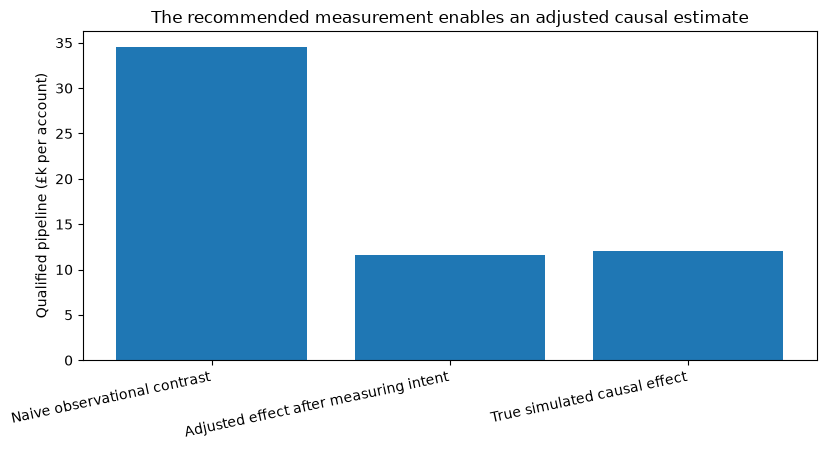

In [21]:
plt.figure(figsize=(8.5, 4.6))
plt.bar(
    outcome_comparison["quantity"],
    outcome_comparison["effect_kgbp_per_account"],
)
plt.ylabel("Qualified pipeline (£k per account)")
plt.title("The recommended measurement enables an adjusted causal estimate")
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

## 9. What the notebook demonstrates

The design ranker distinguishes four questions that are often conflated:

- **Will this action change identification?**
- **Will it only improve precision?**
- **Is it feasible under the declared resource constraints?**
- **Which feasible action should the analyst recommend?**

In this scenario:

- a randomised holdout and a missing-confounder measurement both resolve identification;
- simply adding more observational accounts does not;
- the holdout exceeds the available budget;
- measuring account intent is therefore the best feasible next step;
- after that measurement, an adjusted analysis recovers the simulated campaign effect.

The planning assumptions should be reviewed just as carefully as the causal graph.
A variable should only be registered as an identification unlock when the scientific
argument supports that claim.

## 10. Extensions

Useful next versions of this analysis could:

- rank by expected graph-entropy reduction rather than identification probability;
- rank by expected effect-width reduction after identification is established;
- compare decision utility from deploying, pausing or targeting the campaign;
- use a richer graph posterior produced by a discovery workflow;
- add time-to-result, implementation risk and vendor lock-in to the business layer.

In [22]:
import platform

{
    "python": platform.python_version(),
    "platform": platform.platform(),
    "antecedent": version("antecedent"),
    "design_seed": 11,
    "data_seed": DATA_SEED,
    "accounts": N_ACCOUNTS,
    "budget_gbp": budget_gbp,
    "true_effect_kgbp_per_account": TRUE_EFFECT_KGBP,
}

{'python': '3.13.0',
 'platform': 'macOS-26.5.2-arm64-arm-64bit-Mach-O',
 'antecedent': '1.9.0',
 'design_seed': 11,
 'data_seed': 31,
 'accounts': 1200,
 'budget_gbp': 40000.0,
 'true_effect_kgbp_per_account': 12.0}